In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
pip install openpyxl

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image
import os
import sys

In [20]:
work_dir = '/content/drive/MyDrive/Estudos/Mestrado/Métodos_estatísticos/LE2_Métodos_estatísticos'
input_csv = work_dir + '/servico_publico_dados_corrigido.csv'
output_excel = work_dir + '/questao_15/questao_15_le2.xlsx'

os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

In [21]:
df = pd.read_csv(input_csv)

In [6]:
df.head()

,Região,Área,Ocupação,Opinião,Renda,Idade
0,Dalmácia,Educação,Funcionário público,Indiferente,1.89,29
1,Dalmácia,Infraestrutura,Assalariado/Autônomo,Indiferente,1.63,46
2,Catamarca,Educação,Funcionário público,Insatisfatório,4.50,37
3,Nortúmbria,Infraestrutura,Aposentado,Excelente,1.17,18
4,Querétaro,Infraestrutura,Empresário,Indiferente,2.84,38


## **Questão 15** - Os comentários da questão 11 (“há relação entre o modo de ganhar a vida e a satisfação com o serviço público federal em Pindorama”) são confirmados pelos dados em todas as regiões?  

In [22]:
tabela_regiao = pd.crosstab(index=df['Região'], columns=df['Opinião'])

In [8]:
tabela_regiao

Opinião,Excelente,Indiferente,Insatisfatório,Péssimo,Satisfatório
Região,,,,,
Aquitânia,0,1,32,1495,0
Catamarca,0,283,745,1271,1
Dalmácia,117,2459,375,67,584
Nortúmbria,654,118,0,0,378
Querétaro,0,489,424,167,0


In [23]:
tabela_regiao.index = pd.MultiIndex.from_arrays(
    [tabela_regiao.index, ['Total'] * len(tabela_regiao)],
    names=['Região', 'Ocupação']
)

In [24]:
tabela_abs = pd.crosstab(index=[df['Região'], df['Ocupação']], columns=df['Opinião'])
tabela_completa = pd.concat([tabela_abs, tabela_regiao]).sort_index(level=['Região', 'Ocupação'])

In [25]:
tabela_completa

Opinião                          Excelente  Indiferente  Insatisfatório  \
Região     Ocupação                                                       
Aquitânia  Aposentado                    0            0               0   
           Assalariado/Autônomo          0            1              19   
           Empresário                    0            0               6   
           Funcionário público           0            0               1   
           Profissional liberal          0            0               6   
           Total                         0            1              32   
Catamarca  Aposentado                    0           14              15   
           Assalariado/Autônomo          0          188             507   
           Desempregado                  0            4               2   
           Empresário                    0           17              40   
           Funcionário público           0           36              60   
           Profissional liberal          0           24             121   
           Total                         0          283             745   
Dalmácia   Aposentado                   41          362              24   
           Assalariado/Autônomo         25         1420             244   
           Desempregado                 29          105               8   
           Empresário                    0           21               9   
           Funcionário público          22          472              63   
           Profissional liberal          0           79              27   
           Total                       117         2459             375   
Nortúmbria Aposentado                  175           31               0   
           Assalariado/Autônomo        100           45               0   
           Desempregado                248           16               0   
           Funcionário público         130           23               0   
           Profissional liberal          1            3               0   
           Total                       654          118               0   
Querétaro  Aposentado                    0           38              23   
           Assalariado/Autônomo          0          326             293   
           Desempregado                  0            4               5   
           Empresário                    0            9              18   
           Funcionário público           0           78              40   
           Profissional liberal          0           34              45   
           Total                         0          489             424   

Opinião                          Péssimo  Satisfatório  
Região     Ocupação                                     
Aquitânia  Aposentado                  2             0  
           Assalariado/Autônomo      568             0  
           Empresário                505             0  
           Funcionário público        21             0  
           Profissional liberal      399             0  
           Total                    1495             0  
Catamarca  Aposentado                 16             0  
           Assalariado/Autônomo      764             0  
           Desempregado                1             0  
           Empresário                149             0  
           Funcionário público        53             1  
           Profissional liberal      288             0  
           Total                    1271             1  
Dalmácia   Aposentado                  2           131  
           Assalariado/Autônomo       46           227  
           Desempregado                1            60  
           Empresário                  3             0  
           Funcionário público         3           160  
           Profissional liberal       12             6  
           Total                      67           584  
Nortúmbria Aposentado                  0           109  
           Assalariado/Autônomo        0            96  
      

In [26]:
tabela_percent = tabela_abs.div(tabela_abs.sum(axis=1), axis=0) * 100

In [28]:
tabela_percent.style.background_gradient(cmap='RdYlGn', axis=1)

In [14]:
wb = Workbook()
wb.remove(wb.active)  # remove a planilha padrão

planilhas = {
    'Ocupacao_Opiniao_Absoluto'       : tabela_regiao,
    'Ocupacao_Opiniao_Absoluto_Por_Regiao' : tabela_completa,
    'Ocupacao_Opiniao_Percentual_Por_Regiao'       : tabela_percent
}

for nome, tabela in planilhas.items():
    ws = wb.create_sheet(nome)
    for row in dataframe_to_rows(tabela, index=True, header=True):
        ws.append(row)

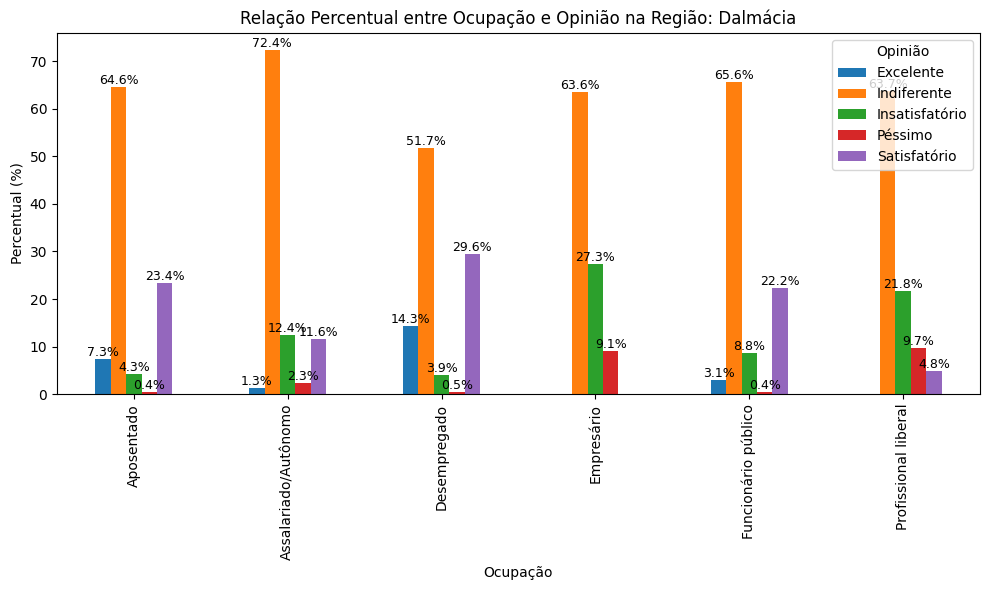

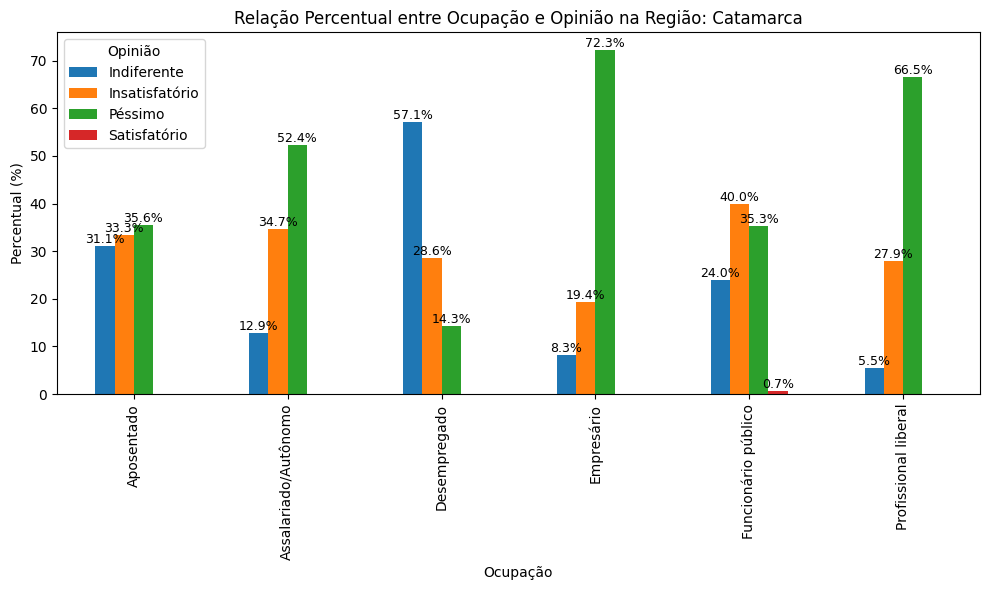

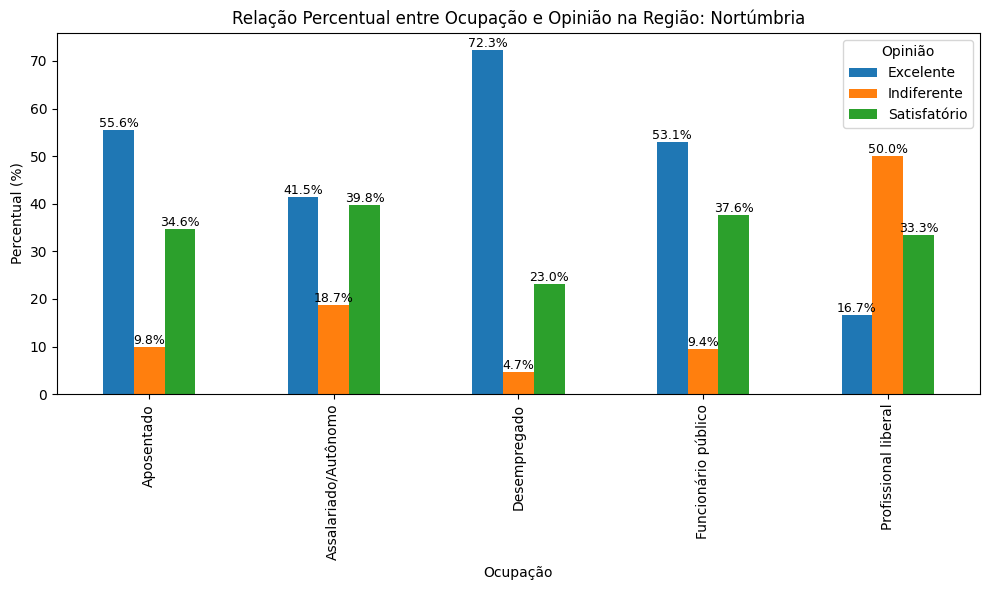

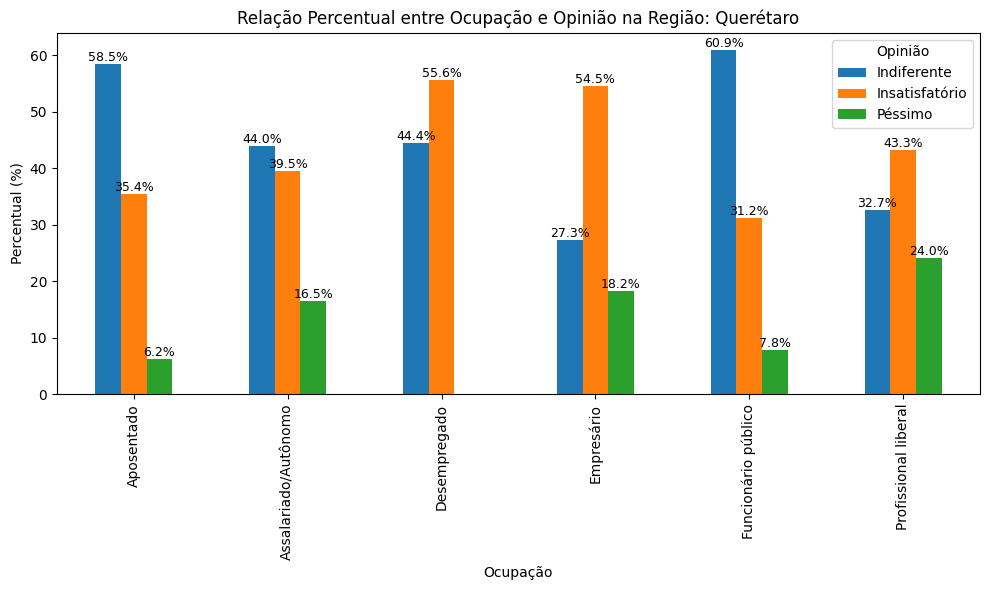

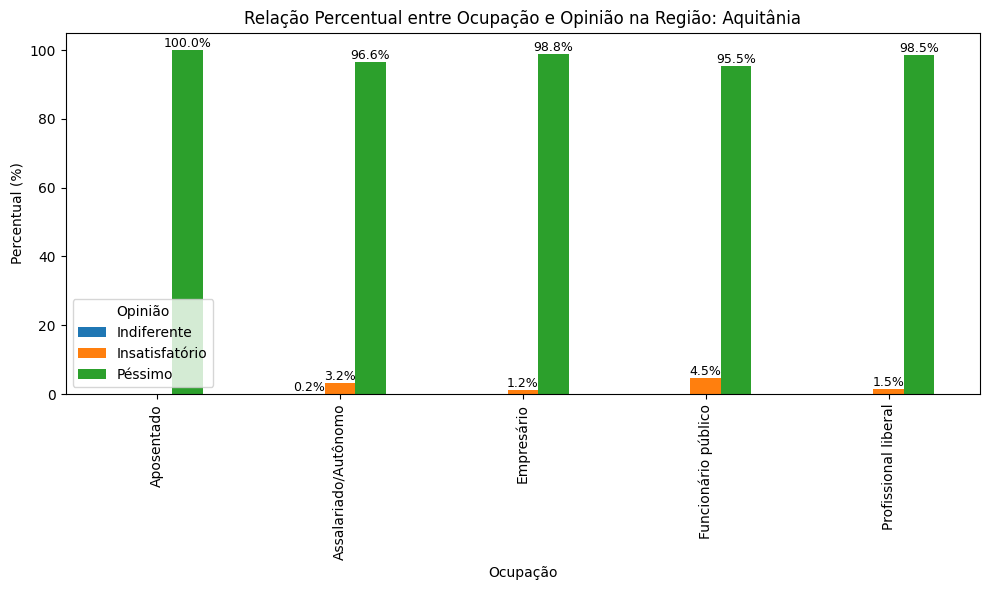

In [15]:
plt.style.use('default')  # Usa o estilo padrão
regioes = df['Região'].unique()
ws = wb.create_sheet('Graficos')
linha = 1

for reg in regioes:
    df_reg = df[df['Região'] == reg]

    # Cria a tabela de contingência de Ocupação x Opinião (valores absolutos)
    tabela = pd.crosstab(df_reg['Ocupação'], df_reg['Opinião'])
    # Converte para percentuais por linha (cada linha soma 100%)
    tabela_percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

    # Plota a tabela de contingência em formato de gráfico de barras, usando os percentuais
    ax = tabela_percent.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Relação Percentual entre Ocupação e Opinião na Região: {reg}')
    plt.xlabel('Ocupação')
    plt.ylabel('Percentual (%)')
    plt.legend(title='Opinião')
    plt.tight_layout()

    # Adiciona rótulos com os percentuais sobre cada barra
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width()/2, height),
                        ha='center', va='bottom', fontsize=9)
    # Salva em PNG na pasta atual
    img_name = f'Relaçao_perc_Ocupacao_Opiniao_{reg}.png'
    plt.savefig(img_name, dpi=150)
    img_file = Image(img_name)
    img_file.anchor = f'A{linha}'
    ws.add_image(img_file)
    linha += 60
    plt.show()

In [16]:
wb.save(output_excel)

## Resposta: Não, essa afirmação não é confirmada em todas as regiões. Na região de Aquitânia todas as ocupações concentram as opiniões em "Péssimo". Já em Dalmácia, todas as ocupações concentram as opiniões em "Indiferente". Em Catamarca, Nortúmbria e Querétaro as opiniões se divergem dependendo da ocupação, ou seja, nessas regiões pode ser que tenha sim relação entre a ocupação e opinião, mas não em todas as regiões.